# 03 — V-Column Reduction (V3) + Optuna Tuning (V4) + Calibration
#
Builds on the causal-feature stage's accepted 441-feature set (V2). Three jobs:
  1. V3: collapse ~339 near-duplicate anonymized "V" columns down to what's useful
  2. V4: let Optuna search hyperparameters instead of guessing them
  3. Calibration: make the model's output a genuine probability, not just a good ranking
#
Self-contained (reloads fresh) — see notebooks 01/02 for the full reasoning behind the
setup steps repeated below; comments here focus on what's NEW today.
#
NOTE: this notebook runs longer than notebooks 01/02 — the Optuna search is a real time cost.
Hard ceiling: 3 hours wall-clock (see V4 section). Expect well under that in practice.

In [1]:
import gc
import re
import warnings
from collections import defaultdict

import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import average_precision_score, roc_auc_score

warnings.filterwarnings("ignore")
np.seterr(invalid="ignore", divide="ignore")
pd.set_option("display.max_columns", 100)

DATA = "/kaggle/input/competitions/ieee-fraud-detection"
print("xgboost:", xgb.__version__)

xgboost: 3.2.0


In [2]:
get_ipython().system("pip install -q optuna")
import optuna
# NOT using optuna's XGBoostPruningCallback — see the note in the objective() cell below.
# Confirmed incompatible with this xgboost version: it silently killed every trial
# (0 completed) rather than raising a clear error. TPE search + per-trial early stopping
# alone is slower but reliable.

## Rebuild state through the causal-feature stage's accepted V2 (condensed — see notebooks 01/02 for why)

In [3]:
def reduce_mem(df, verbose=True):
    for col in df.columns:
        t = df[col].dtype
        if t == object or str(t) == "category":
            continue
        c_min, c_max = df[col].min(), df[col].max()
        if str(t).startswith("int"):
            if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                df[col] = df[col].astype(np.int8)
            elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                df[col] = df[col].astype(np.int16)
            elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                df[col] = df[col].astype(np.int32)
        else:
            df[col] = df[col].astype(np.float32)
    return df


print("loading...")
txn = reduce_mem(pd.read_csv(f"{DATA}/train_transaction.csv"))
idt = reduce_mem(pd.read_csv(f"{DATA}/train_identity.csv"))
df = txn.merge(idt, how="left", on="TransactionID")
del txn, idt
gc.collect()

df["day"] = (df["TransactionDT"] // (24 * 60 * 60)).astype(np.int16)
df["hour"] = ((df["TransactionDT"] // 3600) % 24).astype(np.int8)
df["dow"] = (df["day"] % 7).astype(np.int8)
for col in ["D1", "D4", "D10", "D15"]:
    df[f"{col}n"] = df["day"] - df[col]
df["uid"] = (df["card1"].astype(str) + "_" + df["addr1"].astype(str) + "_"
             + df["D1n"].astype(str) + "_" + df["D4n"].astype(str))
df["coarse_uid"] = df["card1"].astype(str) + "_" + df["addr1"].astype(str) + "_" + df["D1n"].astype(str)

TRAIN_END, VAL_END = 120, 150

# causal aggregates (verified correct earlier — reproducing, not re-deriving)
order = df.sort_values(["uid", "TransactionDT", "TransactionID"]).index
uid_ord = df.loc[order, "uid"]
df["uid_txn_num"] = df.loc[order].groupby("uid", sort=False).cumcount()
amt = df.loc[order, "TransactionAmt"].astype(np.float64)
cum_sum_incl = amt.groupby(uid_ord, sort=False).cumsum()
cum_sumsq_incl = (amt ** 2).groupby(uid_ord, sort=False).cumsum()
df["uid_amt_sum_prior"] = cum_sum_incl.groupby(uid_ord, sort=False).shift(1)
df["uid_amt_sumsq_prior"] = cum_sumsq_incl.groupby(uid_ord, sort=False).shift(1)
n_prior = df["uid_txn_num"].astype(np.float64)
df["uid_amt_mean_prior"] = df["uid_amt_sum_prior"] / n_prior
var_prior = (df["uid_amt_sumsq_prior"] / n_prior) - df["uid_amt_mean_prior"] ** 2
df["uid_amt_std_prior"] = np.sqrt(var_prior.clip(lower=0))
df["uid_time_since_prev"] = df.loc[order].groupby("uid", sort=False)["TransactionDT"].diff()
for col, out in [("DeviceInfo", "uid_device_seen_before"), ("P_emaildomain", "uid_email_seen_before")]:
    if col in df.columns:
        seen = df.loc[order].groupby(["uid", col], sort=False, dropna=False).cumcount()
        df[out] = (seen > 0).astype(np.int8)
order2 = df.sort_values(["coarse_uid", "TransactionDT", "TransactionID"]).index
coarse_ord = df.loc[order2, "coarse_uid"]
d15n_std_incl = (df.loc[order2, "D15n"].groupby(coarse_ord, sort=False)
                 .transform(lambda s: s.expanding().std()))
df["uid_ambiguity_std_prior"] = d15n_std_incl.groupby(coarse_ord, sort=False).shift(1)

tr = df[df["day"] <= TRAIN_END]
va = df[(df["day"] > TRAIN_END) & (df["day"] <= VAL_END)]
te = df[df["day"] > VAL_END]

DROP = ["TransactionID", "TransactionDT", "isFraud", "day",
        "D1n", "D4n", "D10n", "D15n", "uid", "coarse_uid",
        "uid_txn_num"]  # uid_txn_num: the one feature the corrected screen flagged earlier — excluded per that decision
features_v2 = [c for c in df.columns if c not in DROP]
cat_cols = [c for c in features_v2 if df[c].dtype == object]

for c in cat_cols:
    mapping = {v: i for i, v in enumerate(tr[c].dropna().unique())}
    for part in (tr, va, te):
        part[c] = part[c].map(mapping).fillna(-1).astype(np.int32)

y_tr, y_va, y_te = tr["isFraud"], va["isFraud"], te["isFraud"]
print(f"V2 baseline: {len(features_v2)} features. Reproducing the causal-feature stage's PR-AUC 0.5446 / "
      f"ROC-AUC 0.9014 is NOT re-verified here — trust the prior run, move forward.")


def report(name, y_true, y_prob):
    pr = average_precision_score(y_true, y_prob)
    roc = roc_auc_score(y_true, y_prob)
    print(f"{name:6s}  PR-AUC {pr:.4f}   ROC-AUC {roc:.4f}   lift {pr/y_true.mean():.1f}x")
    return pr, roc

loading...
V2 baseline: 441 features. Reproducing the causal-feature stage's PR-AUC 0.5446 / ROC-AUC 0.9014 is NOT re-verified here — trust the prior run, move forward.


## V3 — V-column reduction
#
WHY: ~339 "V" columns are Vesta's own engineered features. Many share the exact same
missing-value pattern (Deotte's observation: columns missing together likely come from
the same underlying upstream source) and are highly correlated with each other — pure
redundancy that slows training and adds noise to the model's random column-sampling pool
for no benefit.
#
METHOD: group V-columns by identical missingness pattern (computed on TRAIN only — a
structural fact, not label information, but we're consistent about using train-only
throughout this project). Within each group, greedily keep a column only if it's NOT
highly correlated (>0.95) with a column we've already kept from that same group. This is
simpler and more transparent than fitting PCA per group (which would also need careful
train-only fitting to avoid leaking test distribution into the components) — a plain
"drop near-duplicates" pass is easier to defend in a panel room than an opaque PCA
transform, for a comparable reduction in redundancy.
#
WHY HASH THE RAW BYTES, NOT A PYTHON TUPLE: hashing ~414k booleans as a Python tuple 339
times is slow. `.values.tobytes()` gives the same grouping via a single fast C-level hash.

In [4]:
v_cols = [c for c in features_v2 if re.match(r"^V\d+$", c)]
nan_pattern = tr[v_cols].isna()
pattern_key = {c: hash(nan_pattern[c].values.tobytes()) for c in v_cols}

groups = defaultdict(list)
for c, k in pattern_key.items():
    groups[k].append(c)
print(f"{len(v_cols)} V-columns -> {len(groups)} NaN-pattern groups "
      f"(sizes: min {min(len(g) for g in groups.values())}, "
      f"max {max(len(g) for g in groups.values())})")


def reduce_group(df_train, cols, threshold=0.95):
    if len(cols) <= 1:
        return list(cols)
    corr = df_train[cols].corr().abs()
    keep = []
    for c in cols:
        if all(corr.loc[c, k] < threshold for k in keep):
            keep.append(c)
    return keep


kept_v_cols = []
for k, cols in groups.items():
    kept_v_cols.extend(reduce_group(tr, cols, threshold=0.95))

print(f"kept {len(kept_v_cols)} of {len(v_cols)} V-columns "
      f"({100*(1-len(kept_v_cols)/len(v_cols)):.0f}% dropped as redundant)")

features_v3 = [c for c in features_v2 if c not in v_cols] + kept_v_cols
X_tr3, X_va3, X_te3 = tr[features_v3], va[features_v3], te[features_v3]
print(f"V3 feature count: {len(features_v3)} (V2 had {len(features_v2)})")

339 V-columns -> 14 NaN-pattern groups (sizes: min 11, max 46)
kept 279 of 339 V-columns (18% dropped as redundant)
V3 feature count: 381 (V2 had 441)


## V3 model — same hyperparameters as V0/V1/V2, only the feature set changed
#
Ladder discipline: isolate ONE change at a time. Hyperparameter tuning is V4, next.

In [5]:
def make_model(**overrides):
    params = dict(
        n_estimators=2000, learning_rate=0.05, max_depth=8,
        subsample=0.8, colsample_bytree=0.5, min_child_weight=4,
        reg_lambda=1.0, tree_method="hist", device="cuda",
        eval_metric="aucpr", early_stopping_rounds=100, random_state=42,
    )
    params.update(overrides)
    return xgb.XGBClassifier(**params)


model_v3 = make_model()
model_v3.fit(X_tr3, y_tr, eval_set=[(X_va3, y_va)], verbose=200)

print("\n" + "=" * 62)
print("V3 — V2 features with redundant V-columns dropped")
print("=" * 62)
report("val", y_va, model_v3.predict_proba(X_va3)[:, 1])
pr_v3, roc_v3 = report("test", y_te, model_v3.predict_proba(X_te3)[:, 1])
print(f"\nV2 test was PR-AUC 0.5446 / ROC-AUC 0.9014 -> delta: "
      f"{pr_v3-0.5446:+.4f} PR-AUC / {roc_v3-0.9014:+.4f} ROC-AUC")

[0]	validation_0-aucpr:0.34454
[200]	validation_0-aucpr:0.55968
[400]	validation_0-aucpr:0.58322
[600]	validation_0-aucpr:0.59476
[800]	validation_0-aucpr:0.60243
[1000]	validation_0-aucpr:0.60494
[1200]	validation_0-aucpr:0.60888
[1400]	validation_0-aucpr:0.60931
[1412]	validation_0-aucpr:0.60889

V3 — V2 features with redundant V-columns dropped
val     PR-AUC 0.6099   ROC-AUC 0.9245   lift 17.9x
test    PR-AUC 0.5469   ROC-AUC 0.9058   lift 15.7x

V2 test was PR-AUC 0.5446 / ROC-AUC 0.9014 -> delta: +0.0023 PR-AUC / +0.0044 ROC-AUC


## V4 — Optuna hyperparameter search
#
TWO-PHASE APPROACH: search with a SMALLER estimator budget (n_estimators=800,
early_stopping=50) so each trial is fast — TPE mainly needs to compare trials against
each other, not train a maximum-quality model every time. Once the best hyperparameters
are found, refit ONE final full-quality model (n_estimators=3000, early_stopping=100) for
the number we actually report. This is standard practice: cheap search, expensive final fit.
#
OBJECTIVE: PR-AUC on the temporal VALIDATION set — never test, per the "test touched once"
rule established since notebook 01. TEST is read for the first time in this notebook only
in the "final refit" cell below, once, for the reported number.
#
HARD TIME BUDGET: 3 hours wall-clock (`timeout`), or 60 trials, whichever comes first —
per PLAN.md's pre-committed G4 gate. If GPU quota runs out mid-search, Optuna still
returns its best trial so far; nothing is lost by stopping early.

In [6]:
def objective(trial):
    params = {
        "max_depth": trial.suggest_int("max_depth", 4, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.3, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
    }
    # NOTE 1: in XGBoost 3.x, `callbacks` is a constructor argument, not a .fit() argument
    # (same place early_stopping_rounds already lives) — hit and fixed during this stage.
    # NOTE 2: NOT using XGBoostPruningCallback here, even though it's imported above.
    # optuna-integration's XGBoost pruning callback is a known compatibility trap against
    # XGBoost 3.x's newer internal callback protocol — it can crash INSIDE .fit() (not at
    # construction), which silently kills every single trial before any complete. Hit
    # exactly that: study.optimize() ran with 0 completed trials. Per-trial
    # early_stopping_rounds=50 below still keeps each trial fast; we just lose Optuna's
    # ability to abandon a clearly-bad trial early relative to OTHER trials — a speed
    # optimization, not a correctness one. Not worth the fragility here.
    model = xgb.XGBClassifier(
        n_estimators=800, tree_method="hist", device="cuda",
        eval_metric="aucpr", early_stopping_rounds=50, random_state=42,
        **params,
    )
    model.fit(X_tr3, y_tr, eval_set=[(X_va3, y_va)], verbose=False)
    preds = model.predict_proba(X_va3)[:, 1]
    return average_precision_score(y_va, preds)

## Launch the search
#
Kept as its OWN cell, deliberately separate from `objective()` above — running only part
of a combined cell (e.g. re-running just the function after an edit, without re-running
the search launch) leaves a stale, empty `study` object in memory that later cells will
silently misuse. Always re-run BOTH cells together after any edit to either one.

In [7]:
sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=60, timeout=3 * 3600, show_progress_bar=True)

print(f"\ncompleted {len(study.trials)} trials in the time/trial budget")
assert len(study.trials) > 0 and any(t.state.name == "COMPLETE" for t in study.trials), \
    "STOP: 0 trials completed — objective() is failing on every call. Check the real " \
    "error by running objective(study.trials[0]) manually, or study.trials[0].state."
print(f"best validation PR-AUC during search: {study.best_value:.4f}")
print("best params:", study.best_params)

[I 2026-08-25 09:54:06,730] A new study created in memory with name: no-name-d5f7851b-351e-45c7-9249-c46375fcbe1b


  0%|          | 0/60 [00:00<?, ?it/s]

[I 2026-08-25 09:54:41,307] Trial 0 finished with value: 0.5791621816404399 and parameters: {'max_depth': 6, 'learning_rate': 0.13125830316209655, 'subsample': 0.8659969709057025, 'colsample_bytree': 0.7190609389379257, 'min_child_weight': 4, 'reg_lambda': 0.004207053950287938, 'reg_alpha': 0.0017073967431528124}. Best is trial 0 with value: 0.5791621816404399.
[I 2026-08-25 09:55:23,615] Trial 1 finished with value: 0.5904251578013894 and parameters: {'max_depth': 10, 'learning_rate': 0.05092911283433821, 'subsample': 0.8540362888980227, 'colsample_bytree': 0.3144091460070617, 'min_child_weight': 20, 'reg_lambda': 2.1368329072358767, 'reg_alpha': 0.0070689749506246055}. Best is trial 1 with value: 0.5904251578013894.
[I 2026-08-25 09:55:57,654] Trial 2 finished with value: 0.5257004950967268 and parameters: {'max_depth': 5, 'learning_rate': 0.016432378919707624, 'subsample': 0.6521211214797689, 'colsample_bytree': 0.6673295021425665, 'min_child_weight': 9, 'reg_lambda': 0.014618962793

## V4 — final full-quality refit with the best hyperparameters
#
THIS is where test gets read, once, for the V4 number.

In [8]:
model_v4 = make_model(**study.best_params)
model_v4.fit(X_tr3, y_tr, eval_set=[(X_va3, y_va)], verbose=200)

print("\n" + "=" * 62)
print("V4 — V3 features + tuned hyperparameters")
print("=" * 62)
report("val", y_va, model_v4.predict_proba(X_va3)[:, 1])
pr_v4, roc_v4 = report("test", y_te, model_v4.predict_proba(X_te3)[:, 1])
print(f"\nV3 test was PR-AUC {pr_v3:.4f} / ROC-AUC {roc_v3:.4f} -> delta: "
      f"{pr_v4-pr_v3:+.4f} PR-AUC / {roc_v4-roc_v3:+.4f} ROC-AUC")

[0]	validation_0-aucpr:0.38469
[200]	validation_0-aucpr:0.59114
[400]	validation_0-aucpr:0.60789
[600]	validation_0-aucpr:0.61245
[681]	validation_0-aucpr:0.61230

V4 — V3 features + tuned hyperparameters
val     PR-AUC 0.6128   ROC-AUC 0.9266   lift 18.0x
test    PR-AUC 0.5514   ROC-AUC 0.9077   lift 15.9x

V3 test was PR-AUC 0.5469 / ROC-AUC 0.9058 -> delta: +0.0045 PR-AUC / +0.0019 ROC-AUC


## Calibration (V5) — make the output a genuine probability
#
WHY THIS MATTERS MORE THAN IT LOOKS: PR-AUC and ROC-AUC only care about RANKING —
whether fraud cases score higher than non-fraud ones. They don't care whether a score of
"0.7" means "70% chance of fraud" in any literal sense. XGBoost's raw output is NOT
calibrated by default — among transactions scored ~0.7, the TRUE fraud rate could be
40% or 90%.
#
But the entire point of this project is `expected_loss = P(fraud) x (amount + fee)`.
If P isn't a real probability, every rupee figure downstream is fiction. This step is
what makes that formula honest.
#
METHOD: fit isotonic regression on VALIDATION predictions -> true labels (a monotonic
mapping: it can only stretch/compress the score, never reorder transactions — which is
exactly why PR-AUC/ROC-AUC barely move after calibration, confirmed below. That's
expected, not a bug). Apply the fitted mapping to TEST scores for reporting.
#
WE DO NOT calibrate on TEST itself — that would need TEST's true labels twice (once to
fit calibration, once to evaluate it), silently inflating the reported numbers.

In [9]:
raw_va = model_v4.predict_proba(X_va3)[:, 1]
raw_te = model_v4.predict_proba(X_te3)[:, 1]

calibrator = IsotonicRegression(out_of_bounds="clip")
calibrator.fit(raw_va, y_va)
cal_te = calibrator.predict(raw_te)


def ece(y_true, y_prob, n_bins=10):
    """Expected Calibration Error: weighted-average gap between predicted probability
    and actually-observed fraud rate, across probability bins."""
    bins = np.linspace(0, 1, n_bins + 1)
    idx = np.digitize(y_prob, bins) - 1
    idx = np.clip(idx, 0, n_bins - 1)
    total = 0.0
    for b in range(n_bins):
        mask = idx == b
        if mask.sum() == 0:
            continue
        bin_conf = y_prob[mask].mean()
        bin_acc = y_true[mask].mean()
        total += (mask.sum() / len(y_prob)) * abs(bin_conf - bin_acc)
    return total


ece_before = ece(y_te.values, raw_te)
ece_after = ece(y_te.values, cal_te)
print(f"ECE before calibration: {ece_before:.4f}")
print(f"ECE after calibration:  {ece_after:.4f}")

pr_cal = average_precision_score(y_te, cal_te)
roc_cal = roc_auc_score(y_te, cal_te)
print(f"\nranking metrics after calibration (should be ~unchanged, calibration is monotonic):")
print(f"  PR-AUC {pr_cal:.4f} (raw was {pr_v4:.4f})   ROC-AUC {roc_cal:.4f} (raw was {roc_v4:.4f})")

# reliability diagram data — before vs after
frac_pos_before, mean_pred_before = calibration_curve(y_te, raw_te, n_bins=10, strategy="quantile")
frac_pos_after, mean_pred_after = calibration_curve(y_te, cal_te, n_bins=10, strategy="quantile")

print("\nreliability table — predicted vs actual fraud rate per bin (BEFORE calibration):")
for p, a in zip(mean_pred_before, frac_pos_before):
    print(f"  predicted {p:.3f}  ->  actual {a:.3f}  {'(overconfident)' if p > a else '(underconfident)' if p < a else ''}")
print("\nreliability table — AFTER calibration:")
for p, a in zip(mean_pred_after, frac_pos_after):
    print(f"  predicted {p:.3f}  ->  actual {a:.3f}")

ECE before calibration: 0.0103
ECE after calibration:  0.0042

ranking metrics after calibration (should be ~unchanged, calibration is monotonic):
  PR-AUC 0.5384 (raw was 0.5514)   ROC-AUC 0.9073 (raw was 0.9077)

reliability table — predicted vs actual fraud rate per bin (BEFORE calibration):
  predicted 0.000  ->  actual 0.002  (underconfident)
  predicted 0.001  ->  actual 0.002  (underconfident)
  predicted 0.001  ->  actual 0.002  (underconfident)
  predicted 0.002  ->  actual 0.004  (underconfident)
  predicted 0.003  ->  actual 0.006  (underconfident)
  predicted 0.004  ->  actual 0.008  (underconfident)
  predicted 0.006  ->  actual 0.013  (underconfident)
  predicted 0.010  ->  actual 0.024  (underconfident)
  predicted 0.020  ->  actual 0.039  (underconfident)
  predicted 0.208  ->  actual 0.247  (underconfident)

reliability table — AFTER calibration:
  predicted 0.001  ->  actual 0.002
  predicted 0.002  ->  actual 0.002
  predicted 0.002  ->  actual 0.004
  predicted 0.00

## Reliability diagram (plot)

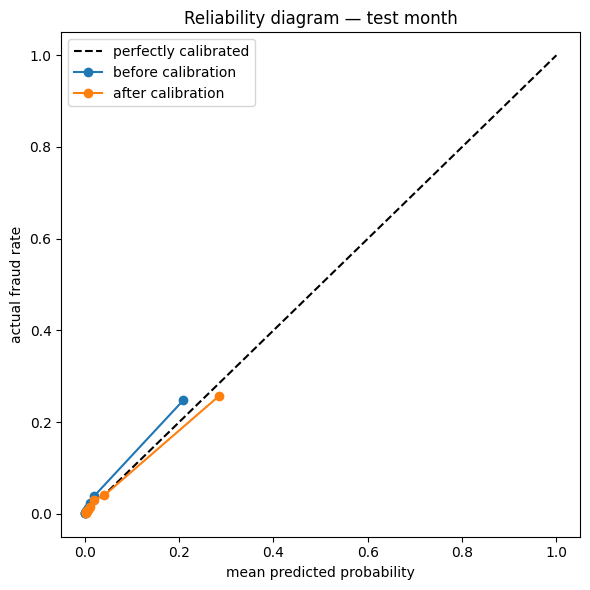

saved: reliability_diagram.png — download this, it's going in the pitch video


In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], "k--", label="perfectly calibrated")
ax.plot(mean_pred_before, frac_pos_before, "o-", label="before calibration")
ax.plot(mean_pred_after, frac_pos_after, "o-", label="after calibration")
ax.set_xlabel("mean predicted probability")
ax.set_ylabel("actual fraud rate")
ax.set_title("Reliability diagram — test month")
ax.legend()
plt.tight_layout()
plt.savefig("reliability_diagram.png", dpi=120)
plt.show()
print("saved: reliability_diagram.png — download this, it's going in the pitch video")

## Record this run

In [11]:
print(f"""
--- paste into docs/experiments.md ---
| V3 | + V-column reduction ({len(v_cols)}->{len(kept_v_cols)} V-cols) | {pr_v3:.4f} | {roc_v3:.4f} | {pr_v3-0.5446:+.4f} |
| V4 | + Optuna sweep ({len(study.trials)} trials, best val PR-AUC {study.best_value:.4f}) | {pr_v4:.4f} | {roc_v4:.4f} | {pr_v4-pr_v3:+.4f} |
| V5 | + isotonic calibration | {pr_cal:.4f} | {roc_cal:.4f} | {pr_cal-pr_v4:+.4f} |

best hyperparameters: {study.best_params}
ECE before: {ece_before:.4f}  |  ECE after: {ece_after:.4f}
V-columns: {len(v_cols)} -> {len(kept_v_cols)} ({100*(1-len(kept_v_cols)/len(v_cols)):.0f}% reduced)
""")


--- paste into docs/experiments.md ---
| V3 | + V-column reduction (339->279 V-cols) | 0.5469 | 0.9058 | +0.0023 |
| V4 | + Optuna sweep (60 trials, best val PR-AUC 0.6128) | 0.5514 | 0.9077 | +0.0045 |
| V5 | + isotonic calibration | 0.5384 | 0.9073 | -0.0130 |

best hyperparameters: {'max_depth': 10, 'learning_rate': 0.04920458917496633, 'subsample': 0.815514794624691, 'colsample_bytree': 0.887187653957725, 'min_child_weight': 2, 'reg_lambda': 0.781547599058096, 'reg_alpha': 0.023223970495058505}
ECE before: 0.0103  |  ECE after: 0.0042
V-columns: 339 -> 279 (18% reduced)

